In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

In [2]:
import geoflowkit as gfk

In [3]:
flow_num = 5000
xlim, ylim = (0, 1), (0, 1)

oxs = np.random.uniform(xlim[0], xlim[1], flow_num)
oys = np.random.uniform(ylim[0], ylim[1], flow_num)
dxs = np.random.uniform(xlim[0], xlim[1], flow_num)
dys = np.random.uniform(ylim[0], ylim[1], flow_num)
data = np.vstack([oxs, oys, dxs, dys]).T

fdf = gfk.FlowDataFrame(data, columns=['ox', 'oy', 'dx', 'dy'], 
                        geometry=gfk.flows_from_od(data[:, :2], data[:, -2:]), crs='EPSG:4526')
fdf.head(1)

,ox,oy,dx,dy,geometry
0,0.621181,0.29514,0.888102,0.83847,"MULTIPOINT (0.621 0.295, 0.888 0.838)"


In [4]:
dis_matrix = gfk.pairwise_distances(fdf, distance='max')
dis_matrix.shape

(5000, 5000)

## K Function

In [5]:
polygon = Polygon([(0.3, 0.3), (0.7, 0.3), (0.7, 0.7), (0.3, 0.7)])
x, y = polygon.exterior.xy
r_list, kr_list = gfk.k_func(fdf, dr=0.01, dis_matrix=dis_matrix, distance='max', mask=polygon)

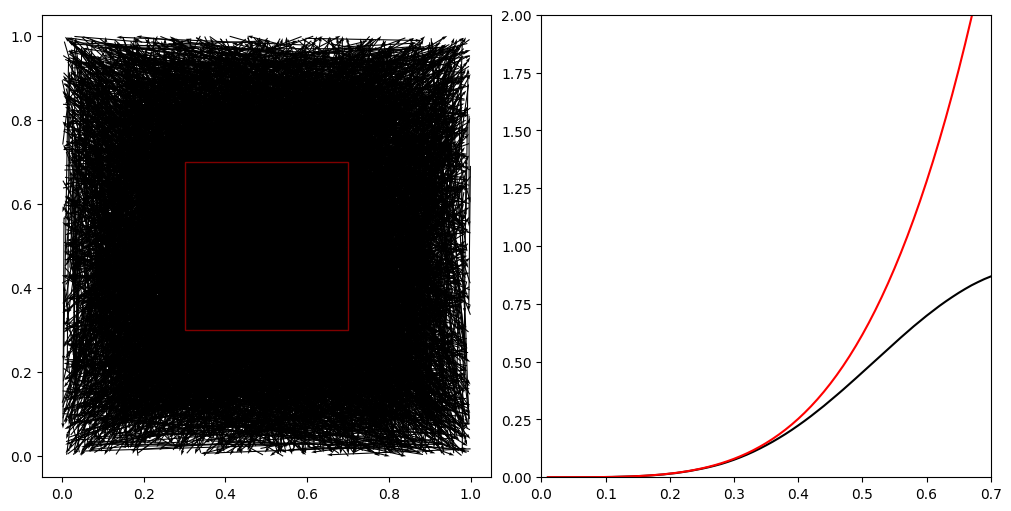

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

fdf.plot(figsize=(6, 6), ax=ax1)
ax1.fill(x, y, alpha=0.5, fc='none', ec='red')

ax2.plot(r_list, kr_list, 'k-')
ax2.plot(r_list, np.pi**2 * r_list**4, 'r-')
ax2.set_xlim(0, 0.7)
ax2.set_ylim(0, 2);

## L Function

In [7]:
polygon = Polygon([(0.3, 0.3), (0.7, 0.3), (0.7, 0.7), (0.3, 0.7)])
x, y = polygon.exterior.xy
r_list, lr_list = gfk.l_func(fdf, dr=0.01, dis_matrix=dis_matrix, distance='max', mask=polygon)

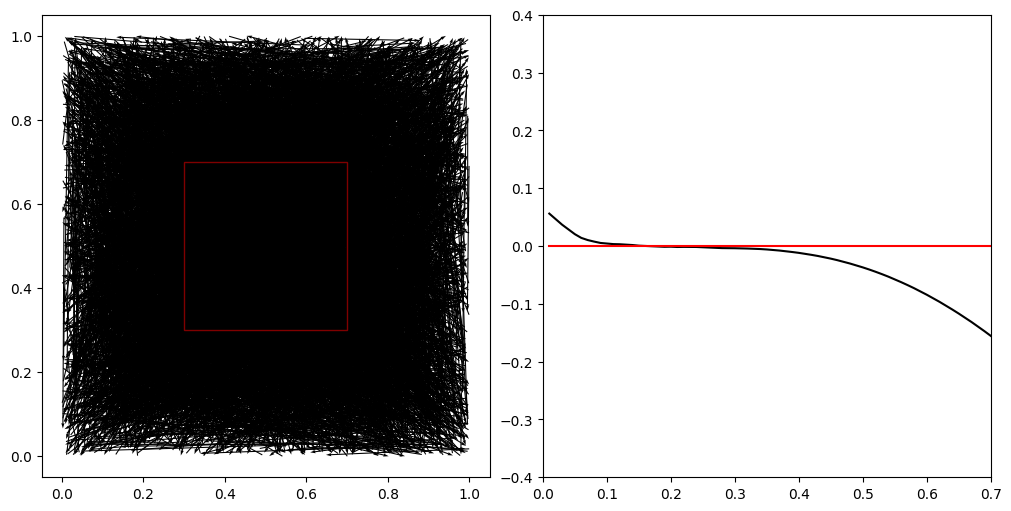

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

fdf.plot(figsize=(6, 6), ax=ax1)
ax1.fill(x, y, alpha=0.5, fc='none', ec='red')

ax2.plot(r_list, lr_list, 'k-')
ax2.plot(r_list, np.zeros_like(r_list), 'r-')
ax2.set_xlim(0, 0.7)
ax2.set_ylim(-0.4, 0.4);